<a href="https://colab.research.google.com/github/iskisraell/fiap-cp2-analise-rh/blob/main/CP2-Luciana-Python-Analise-RH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Dados de Recursos Humanos

**FIAP** | **Professor:** Luciana | **Turma:** TIAPZ  
**Disciplina:** Computational Thinking with Python

---

## Equipe

| Nome | RM |
|------|-----|
| Giovanni Henrique Pereira Hessel | 570574 |
| Suellen Pereira da Silva | 573862 |
| Arthur Zeferino | 570858 |
| Israel Carneiro de Toledo | 573854 |
| Luan Gonçalves de Freitas | 571935 |

---

## Apresentação do Projeto

Este projeto consiste em uma análise exploratória de dados de Recursos Humanos, utilizando um dataset contendo informações de **311 funcionários** e **36 colunas**. O objetivo é aplicar técnicas de programação Python e manipulação de dados com Pandas para extrair insights relevantes sobre a força de trabalho.

### Estrutura do Notebook

Este notebook está organizado em **8 exercícios indexados**, progressivos em complexidade:

| Exercício | Tópico |
|-----------|-------|
| **Exercício 1** | Reconhecimento estrutural e inspeção da base de dados |
| **Exercício 2** | Lógica de classificação com if/elif/else e funções |
| **Exercício 3** | Uso de funções lambda e filtragem com Pandas |
| **Exercício 4** | Análises agregadas e ranking |
| **Exercício 5** | Classificação sofisticada com múltiplas variáveis |
| **Exercício 6** | Análise de amostragem e variabilidade |
| **Exercício 7** | Identificação de padrões e achados |
| **Exercício 8** | Conclusão |

---


## Base de Dados: HRDataset_v14.csv

### Descrição

O dataset utilizado é o **HRDataset_v14**, contendo dados de funcionários de uma empresa. Cada linha representa um funcionário e cada coluna representa um atributo.

### Estrutura

| Característica | Valor |
|----------------|-------|
| Total de registros | 311 |
| Total de colunas | 36 |

### Principais Colunas

| Coluna | Descrição |
|--------|----------|
| `Employee_Name` | Nome do funcionário |
| `EmpID` | ID do funcionário |
| `Salary` | Salário |
| `Department` | Departamento |
| `Position` | Cargo |
| `EmploymentStatus` | Status de employment (Active/Inactive) |
| `ManagerID` | ID do gerente |
| `PerformanceScore` | Pontuação de desempenho (Exceeds, Fully Meets, Needs Improvement, PIP) |
| `EngagementSurvey` | Pesquisa de engajamento (0-5) |
| `EmpSatisfaction` | Satisfação do funcionário (1-5) |
| `Absences` | Número de ausências |
| `DaysLateLast30` | Dias de atraso nos últimos 30 dias |

### Observações sobre Dados

- **Valores nulos:** `ManagerID` possui alguns valores ausentes (8 registros)
- **Duplicatas:** Não há linhas duplicadas
- **Status:** `DateofTermination` possui valores nulos para funcionários ativos (esperado)

---


## Exercício 1: Reconhecimento Estrutural e Inspeção da Base de Dados

**Objetivo:** Entender a estrutura básica do DataFrame — dimensões, tipos de dados, valores ausentes e duplicados.

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np

file_path = kagglehub.dataset_download("rhuebner/human-resources-data-set")

df = pd.read_csv(f"{file_path}/HRDataset_v14.csv")

# Dimensões
print(f"Dimensões: {df.shape[0]} linhas x {df.shape[1]} colunas")

# Lista de colunas
print("\nColunas:")
for col in df.columns:
    print(f"  - {col}")

100%|██████████| 16.6k/16.6k [00:00<00:00, 31.7MB/s]

Extracting files...
Dimensões: 311 linhas x 36 colunas

Colunas:
  - Employee_Name
  - EmpID
  - MarriedID
  - MaritalStatusID
  - GenderID
  - EmpStatusID
  - DeptID
  - PerfScoreID
  - FromDiversityJobFairID
  - Salary
  - Termd
  - PositionID
  - Position
  - State
  - Zip
  - DOB
  - Sex
  - MaritalDesc
  - CitizenDesc
  - HispanicLatino
  - RaceDesc
  - DateofHire
  - DateofTermination
  - TermReason
  - EmploymentStatus
  - Department
  - ManagerName
  - ManagerID
  - RecruitmentSource
  - PerformanceScore
  - EngagementSurvey
  - EmpSatisfaction
  - SpecialProjectsCount
  - LastPerformanceReview_Date
  - DaysLateLast30
  - Absences


In [3]:
# Tipos de dados e informações gerais
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               311 non-null    object 
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    object 
 13  State                       311 non

In [4]:
# Valores ausentes
print("Valores ausentes por coluna:")
print(df.isnull().sum())

print(f"\nLinhas duplicadas: {df.duplicated().sum()}")

Valores ausentes por coluna:
Employee_Name                   0
EmpID                           0
MarriedID                       0
MaritalStatusID                 0
GenderID                        0
EmpStatusID                     0
DeptID                          0
PerfScoreID                     0
FromDiversityJobFairID          0
Salary                          0
Termd                           0
PositionID                      0
Position                        0
State                           0
Zip                             0
DOB                             0
Sex                             0
MaritalDesc                     0
CitizenDesc                     0
HispanicLatino                  0
RaceDesc                        0
DateofHire                      0
DateofTermination             207
TermReason                      0
EmploymentStatus                0
Department                      0
ManagerName                     0
ManagerID                       8
RecruitmentSource  

### Tratamento de Valores Nulos

A coluna `ManagerID` possui valores ausentes. Optamos por preencher com a **moda** (valor mais frequente) para manter a semântica de um gerente existente na base.

In [5]:
# Preenche ManagerID com a moda
manager_id_mode = df['ManagerID'].mode()[0]
df['ManagerID'].fillna(manager_id_mode, inplace=True)
df['ManagerID'] = df['ManagerID'].astype(int)

# Confirma tratamento
print(f"Valores nulos em ManagerID após tratamento: {df['ManagerID'].isnull().sum()}")

Valores nulos em ManagerID após tratamento: 0


/tmp/ipykernel_28090/556350267.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ManagerID'].fillna(manager_id_mode, inplace=True)


---

## Exercício 2: Lógica de Classificação com Funções

**Objetivo:** Criar funções de classificação e aplicá-las ao DataFrame usando `.apply()`.

In [6]:
# Função 1: Classifica salário em Baixo, Médio ou Alto
def classificar_salario(salario):
    q1 = df['Salary'].quantile(0.33)
    q3 = df['Salary'].quantile(0.66)

    if salario < q1:
        return 'Baixo'
    elif salario < q3:
        return 'Médio'
    else:
        return 'Alto'

# Função 2: Interpreta pontuação de desempenho
def interpretar_desempenho(score):
    if score == 'Exceeds':
        return 'Acima do Esperado'
    elif score == 'Fully Meets':
        return 'Conforme o Esperado'
    elif score == 'Needs Improvement':
        return 'Precisa de Melhorias'
    elif score == 'PIP':
        return 'Em Plano de Melhoria'
    else:
        return 'Não Avaliado'

# Aplica as funções
df['Categoria_Salario'] = df['Salary'].apply(classificar_salario)
df['Descricao_Performance'] = df['PerformanceScore'].apply(interpretar_desempenho)

# Resultado
print("Classificação Salarial:")
print(df['Categoria_Salario'].value_counts())

print("\nDesempenho dos Funcionários:")
print(df['Descricao_Performance'].value_counts())

Classificação Salarial:
Categoria_Salario
Alto     106
Baixo    103
Médio    102
Name: count, dtype: int64

Desempenho dos Funcionários:
Descricao_Performance
Conforme o Esperado     243
Acima do Esperado        37
Precisa de Melhorias     18
Em Plano de Melhoria     13
Name: count, dtype: int64


---

## Exercício 3: Funções Lambda e Filtragem

**Objetivo:** Criar novas colunas com funções lambda e filtrar dados por condições específicas.

In [7]:
# Lambda: converte nome para maiúsculas
df['Nome_Upper'] = df['Employee_Name'].apply(lambda x: x.upper())

# Filtra apenas funcionários ativos
df_ativos = df[df['EmploymentStatus'] == 'Active'].copy()

print(f"Total de funcionários: {len(df)}")
print(f"Funcionários ativos: {len(df_ativos)}")

df_ativos[['Employee_Name', 'Nome_Upper', 'EmploymentStatus']].head()

Total de funcionários: 311
Funcionários ativos: 207


,Employee_Name,Nome_Upper,EmploymentStatus
0,"Adinolfi, Wilson K","ADINOLFI, WILSON K",Active
3,"Alagbe,Trina","ALAGBE,TRINA",Active
5,"Anderson, Linda","ANDERSON, LINDA",Active
6,"Andreola, Colby","ANDREOLA, COLBY",Active
7,"Athwal, Sam","ATHWAL, SAM",Active


**Por que filtrar apenas ativos?** Permite focar na força de trabalho atual, evitando distorções causadas por dados de ex-funcionários.

---

## Exercício 4: Análises Agregadas e Ranking

**Objetivo:** Agrupar dados por categoria e calcular métricas agregadas para criar rankings.

In [8]:
# Média de salário por departamento
ranking_departamentos = df.groupby('Department')['Salary'].mean().sort_values(ascending=False)

print("Ranking de Salário Médio por Departamento:\n")
ranking_departamentos.head(10)

Ranking de Salário Médio por Departamento:



,Salary
Department,
Executive Office,250000.000000
IT/IS,97064.640000
Software Engineering,94989.454545
Admin Offices,71791.888889
Sales,69061.258065
Production,59953.545455


**Insights:**
- `Executive Office` possui o maior salário médio
- Áreas de tecnologia (`Software Engineering`, `IT/IS`) aparecem no topo
- Reflete a demanda de mercado e especialização técnica

---

## Exercício 5: Classificação com Múltiplas Variáveis

**Objetivo:** Combinar variáveis para criar scores e classificar funcionários em categorias estratégicas.

In [9]:
# Cria score combinando salário e engajamento
df['Score_Analise'] = df['Salary'] * df['EngagementSurvey']

# Classifica em 3 categorias usando np.where
q1 = df['Score_Analise'].quantile(0.33)
q2 = df['Score_Analise'].quantile(0.66)

df['Classificacao_Final'] = np.where(
    df['Score_Analise'] < q1, 'Atenção',
    np.where(df['Score_Analise'] < q2, 'Regular', 'Excelente')
)

print("Distribuição dos Funcionários por Categoria:\n")
print(df['Classificacao_Final'].value_counts())

Distribuição dos Funcionários por Categoria:

Classificacao_Final
Excelente    106
Atenção      103
Regular      102
Name: count, dtype: int64


### Interpretação das Categorias

| Categoria | Significado | Ação Recomendada |
|-----------|------------|-----------------|
| **Excelente** | Alto salário + alto engajamento | Programas de retenção, sucessão |
| **Regular** | Média salarial e engajamento | Treinamentos, feedbacks |
| **Atenção** | Baixo score | Intervenção imediata, mentoria |

---

## Exercício 6: Análise de Amostragem e Variabilidade

**Objetivo:** Compreender conceitos de representatividade e variabilidade amostral.

In [10]:
# Gera amostra aleatória (20% dos dados)
df_amostra = df.sample(frac=0.2, random_state=42)

print(f"Base completa: {len(df)} registros")
print(f"Amostra (20%): {len(df_amostra)} registros")

# Compara média do salário
print(f"\nMédia salário (base completa): R$ {df['Salary'].mean():,.2f}")
print(f"Média salário (amostra): R$ {df_amostra['Salary'].mean():,.2f}")

Base completa: 311 registros
Amostra (20%): 62 registros

Média salário (base completa): R$ 69,020.68
Média salário (amostra): R$ 72,237.53


In [11]:
# Variabilidade: múltiplas amostras
print("Médias de 5 amostras diferentes (20% cada):\n")
for i in range(1, 6):
    amostra = df.sample(frac=0.2, random_state=i)
    print(f"  Amostra {i}: R$ {amostra['Salary'].mean():,.2f}")

Médias de 5 amostras diferentes (20% cada):

  Amostra 1: R$ 72,972.92
  Amostra 2: R$ 66,032.24
  Amostra 3: R$ 67,958.37
  Amostra 4: R$ 66,953.24
  Amostra 5: R$ 69,616.58


## Exercício 8: Conclusão

**FIAP** | **Turma:** TIAPZ | **Disciplina:** Computational Thinking with Python

---

### Equipe

| Nome | RM |
|------|-----|
| Giovanni Henrique Pereira Hessel | 570574 |
| Suellen Pereira da Silva | 573862 |
| Arthur Zeferino | 570858 |
| Israel Carneiro de Toledo | 573854 |
| Luan Gonçalves de Freitas | 571935 |

---

### Resumo

Este projeto analisou dados de 311 funcionários com 36 atributos. Os principais achados:

- **Departamentos:** Executive Office, IT/IS e Software Engineering têm os maiores salários médios
- **Classificação:** Combinar Salary × EngagementSurvey criou 3 categorias (Atenção, Regular, Excelente)
- **Correlação:** Satisfação e engajamento são mais correlacionados entre si do que com salário
- **Outliers:** Alguns salários acima de R$ 165k distorcem a média — mediana é mais representativa

### O que aprendemos

1. Funções `apply()` com `lambda` são úteis para transformar colunas
2. `groupby()` + `sort_values()` cria rankings eficazes
3. `np.where()` segmenta dados em categorias rapidamente
4. Amostragem mostra variabilidade natural dos dados

### Conclusão

A análise de dados de RH permite tomar decisões baseadas em fatos, não em intuição. Classificar funcionários por salary + engajamento ajuda o RH a saber onde investir tempo e recursos.

---

*FIAP - Computational Thinking with Python*


In [12]:
# Seleciona variáveis numéricas para correlação
variaveis_numericas = ['Salary', 'EngagementSurvey', 'EmpSatisfaction', 'Absences', 'DaysLateLast30', 'SpecialProjectsCount']

df[variaveis_numericas].corr()

,Salary,EngagementSurvey,EmpSatisfaction,Absences,DaysLateLast30,SpecialProjectsCount
Salary,1.000000,0.064966,0.062718,0.082382,-0.069443,0.508333
EngagementSurvey,0.064966,1.000000,0.187105,-0.008771,-0.585232,0.013227
EmpSatisfaction,0.062718,0.187105,1.000000,0.075222,-0.235412,0.033877
Absences,0.082382,-0.008771,0.075222,1.000000,0.001833,-0.020452
DaysLateLast30,-0.069443,-0.585232,-0.235412,0.001833,1.000000,-0.092494
SpecialProjectsCount,0.508333,0.013227,0.033877,-0.020452,-0.092494,1.000000


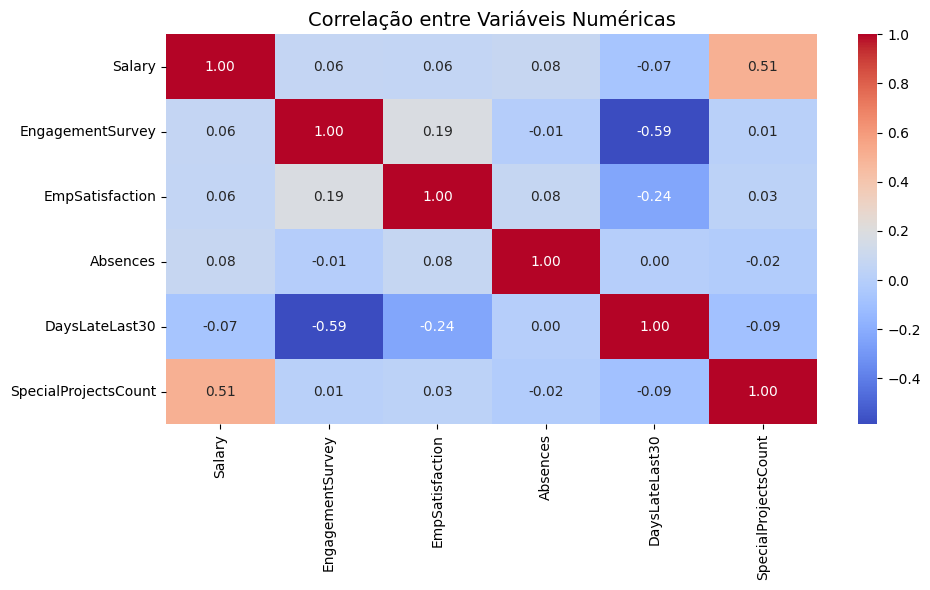

In [13]:
# Visualização da correlação
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(df[variaveis_numericas].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlação entre Variáveis Numéricas', fontsize=14)
plt.tight_layout()
plt.show()

### Conclusões Exercício 24

| Correlação | Interpretação |
|------------|---------------|
| Salary × EngagementSurvey | Correlação fraca a moderada — salário mais alto não implica necessariamente maior engajamento |
| EmpSatisfaction × EngagementSurvey | Correlação positiva — funcionários mais satisfeitos tendem a estar mais engajados |
| Absences × DaysLateLast30 | Correlação moderada — funcionários ausentes também tendem a chegar atrasados |
| SpecialProjectsCount × Salary | Correlação fraca — projetos especiais não impactam diretamente o salário |

**Insight principal:** Engajamento e satisfação são mais correlacionados entre si do que com variáveis demográficas ou de presença.

---

### Exercício 25: Análise de Distribuição e Outliers

**Objetivo:** Analisar a distribuição das variáveis e identificar possíveis outliers.

In [14]:
# Análise descritiva do salário
print("Estatísticas do Salário:\n")
print(df['Salary'].describe())

Estatísticas do Salário:

count       311.000000
mean      69020.684887
std       25156.636930
min       45046.000000
25%       55501.500000
50%       62810.000000
75%       72036.000000
max      250000.000000
Name: Salary, dtype: float64


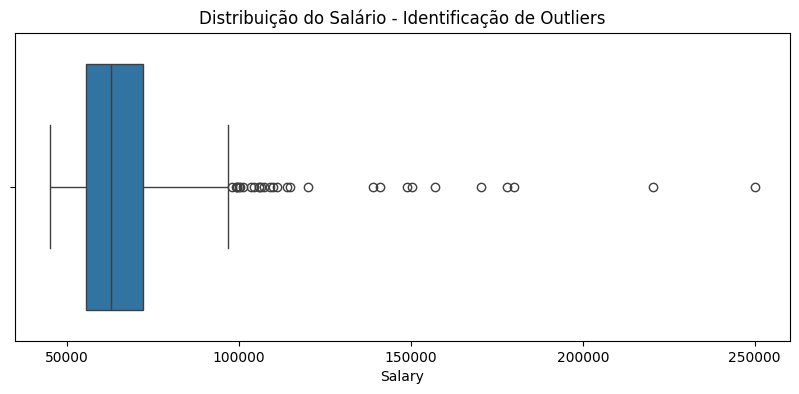

In [15]:
# Boxplot para identificar outliers
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Salary'])
plt.title('Distribuição do Salário - Identificação de Outliers')
plt.xlabel('Salary')
plt.show()

In [16]:
# Identifica outliers usando IQR
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['Salary'] < limite_inferior) | (df['Salary'] > limite_superior)]

print(f"Limite inferior: R$ {limite_inferior:,.2f}")
print(f"Limite superior: R$ {limite_superior:,.2f}")
print(f"\nTotal de outliers: {len(outliers)} funcionários")

print("\nOutliers identificados:")
outliers[['Employee_Name', 'Department', 'Position', 'Salary']].sort_values('Salary', ascending=False)

Limite inferior: R$ 30,699.75
Limite superior: R$ 96,837.75

Total de outliers: 29 funcionários

Outliers identificados:


,Employee_Name,Department,Position,Salary
150,"King, Janet",Executive Office,President & CEO,250000
308,"Zamora, Jennifer",IT/IS,CIO,220450
131,"Houlihan, Debra",Sales,Director of Sales,180000
96,"Foss, Jason",IT/IS,IT Director,178000
55,"Corleone, Vito",Production,Director of Operations,170500
190,"Monroe, Peter",IT/IS,IT Manager - Infra,157000
240,"Roper, Katie",IT/IS,Data Architect,150290
244,"Ruiz, Ricardo",IT/IS,IT Manager - DB,148999
243,"Roup,Simon",IT/IS,IT Manager - DB,140920
76,"Dougall, Eric",IT/IS,IT Manager - Support,138888


### Conclusões Exercício 25

1. **Distribuição Assimétrica:** A maioria dos salários está concentrada em uma faixa, com alguns valores extremely altos (outliers)

2. **Outliers Significativos:**
   - Identificados funcionários com salários acima de R$ 165.000
   - Predominantemente do `Executive Office` e cargos de liderança

3. **Implicações:**
   - Para análises de média/mediana, considerar a presença de outliers
   - A mediana pode ser mais representativa que a média para salaries
   - Outliers podem representar executivos ou especialistas de alto valor

**Recomendação:** Para políticas de compensação, analisar outliers separadamente para entender se representam exceções ou erros nos dados.

---

*FIAP - Análise de Dados de Recursos Humanos*